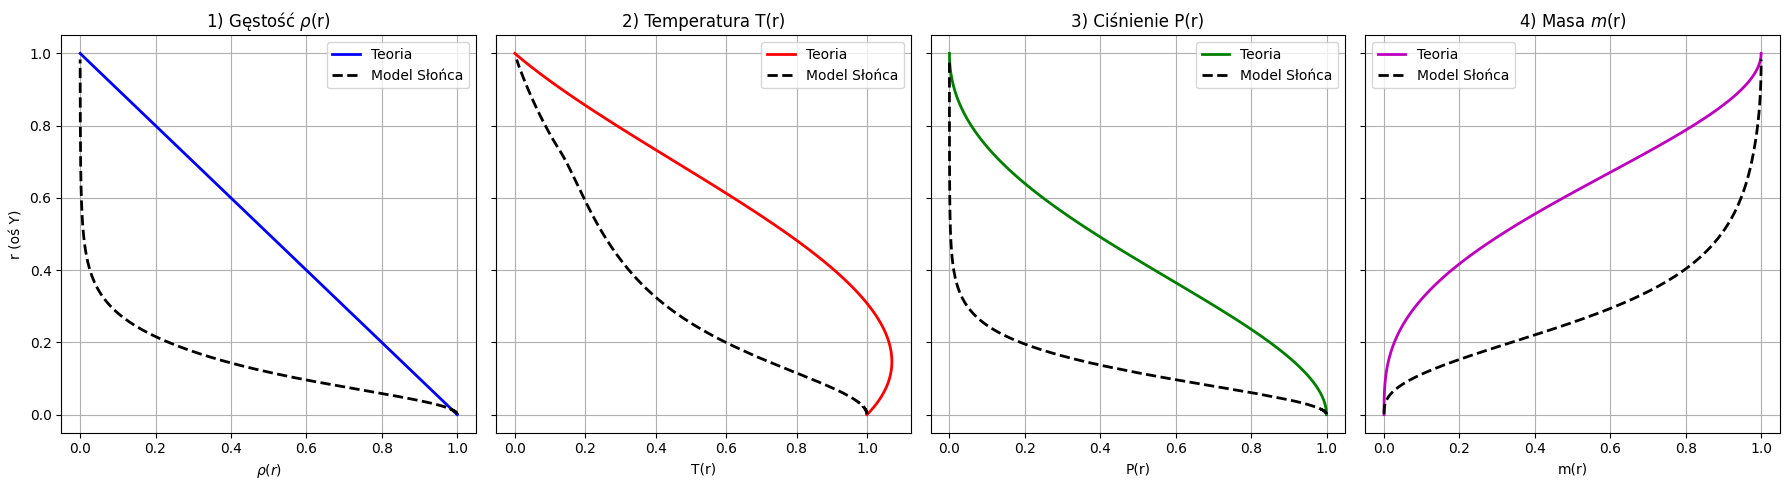

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Wczytywanie i normalizacja danych z oryginalnego pliku .dat
# ---------------------------------------------------------
# Automatyczne wczytanie pliku - pomija puste linie i te z '#'
data = np.loadtxt('Standard_Solar_Model.dat', comments='#')

# Wyciągnięcie odpowiednich kolumn na podstawie struktury pliku
m_data   = data[:, 0]  # Kolumna 1: M/Msun
r_data   = data[:, 1]  # Kolumna 2: R/Rsun
T_data   = data[:, 2]  # Kolumna 3: T [K]
rho_data = data[:, 3]  # Kolumna 4: Rho [g/cm^3]
P_data   = data[:, 4]  # Kolumna 5: P [dyn/cm^2]

# Normalizacja danych fizycznych do wartości w centrum Słońca (indeks 0).
# Dzięki temu zrównamy je z zakresem 0-1, z którego korzysta Twój model teoretyczny.
T_data_norm   = T_data / T_data[0]
rho_data_norm = rho_data / rho_data[0]
P_data_norm   = P_data / P_data[0]
# Zmienna 'm_data' to już ułamek masy Słońca (M/Msun), więc nie musimy jej normalizować.
# ---------------------------------------------------------

# Zdefiniowanie osi Y (r) w przedziale od 0 do 1 dla funkcji teoretycznej
r = np.linspace(0, 1, 100)

# Zdefiniowanie modeli analitycznych
rho = 1 - r
T = 1 + r - (19/5)*r**2 + (9/5)*r**3
P = 1 - (24/5)*r**2 + (28/5)*r**3 - (9/5)*r**4
m = (4 - 3*r) * r**3

# Utworzenie figury z czterema panelami ułożonymi obok siebie
fig, axs = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

# 1. Wykres funkcji rho
axs[0].plot(rho, r, 'b-', linewidth=2, label='Teoria')
axs[0].plot(rho_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[0].set_ylabel('r (oś Y)')
axs[0].set_xlabel(r'$\rho(r)$')
axs[0].set_title(r'1) Gęstość $\rho$(r)')
axs[0].grid(True)
axs[0].legend()

# 2. Wykres funkcji T
axs[1].plot(T, r, 'r-', linewidth=2, label='Teoria')
axs[1].plot(T_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[1].set_xlabel('T(r)')
axs[1].set_title('2) Temperatura T(r)')
axs[1].grid(True)
axs[1].legend()

# 3. Wykres funkcji P
axs[2].plot(P, r, 'g-', linewidth=2, label='Teoria')
axs[2].plot(P_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[2].set_xlabel('P(r)')
axs[2].set_title('3) Ciśnienie P(r)')
axs[2].grid(True)
axs[2].legend()

# 4. Wykres funkcji m
axs[3].plot(m, r, 'm-', linewidth=2, label='Teoria') 
axs[3].plot(m_data, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[3].set_xlabel('m(r)')
axs[3].set_title(r'4) Masa $m$(r)')
axs[3].grid(True)
axs[3].legend()

# Dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()

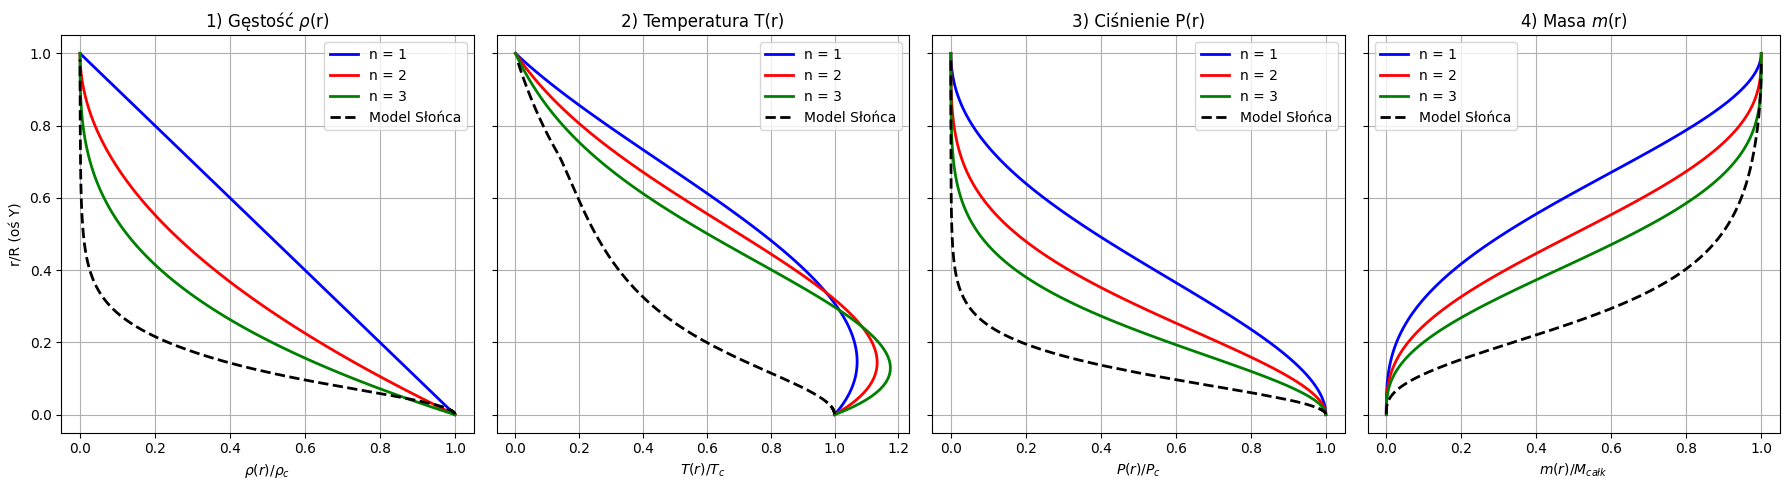

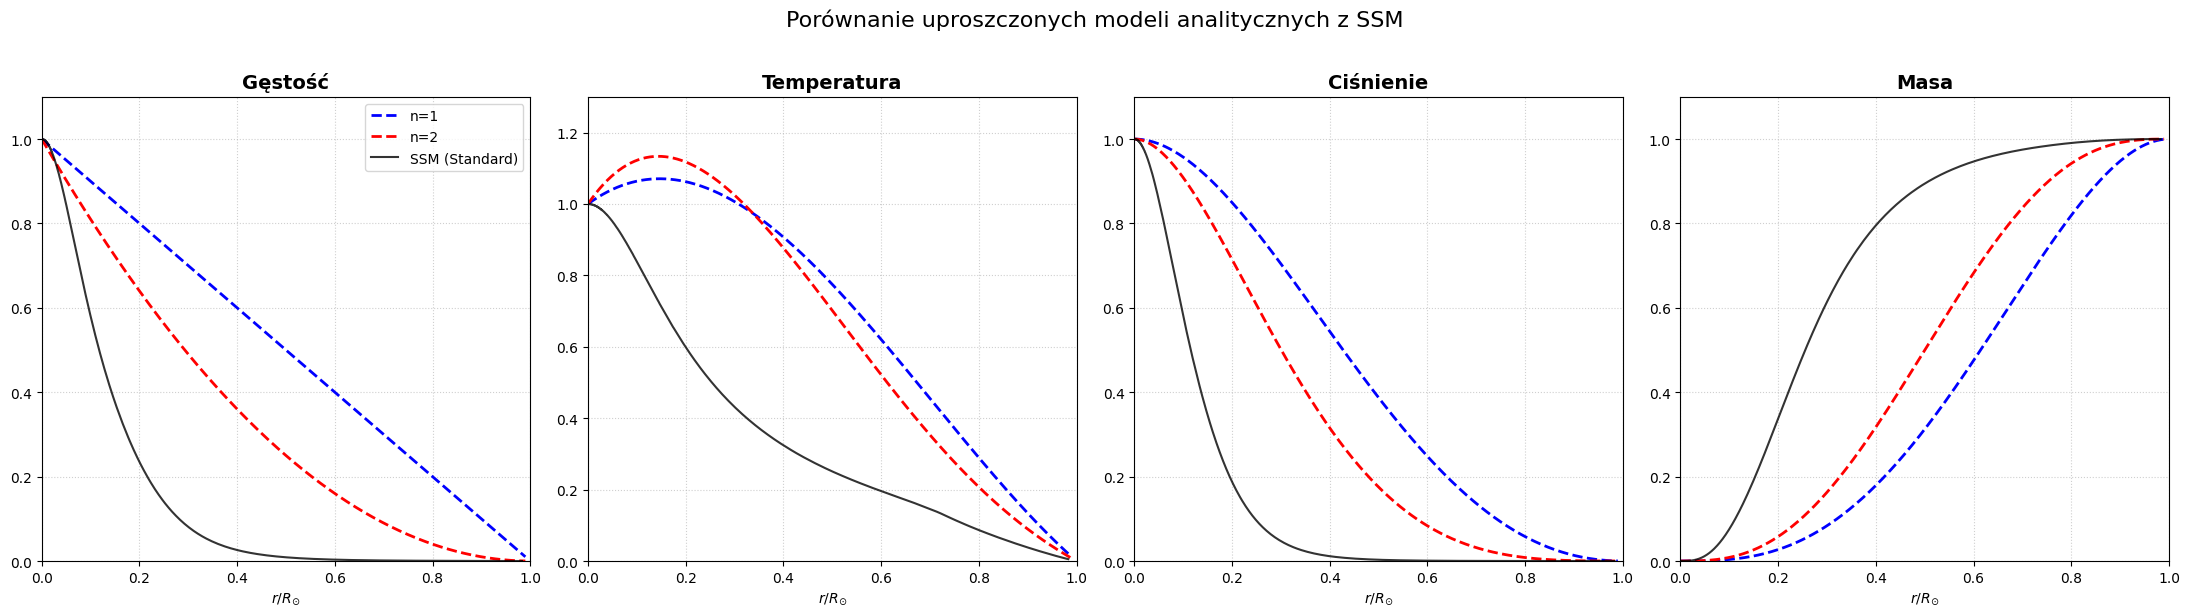

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Wczytanie danych SSM
try:
    data = np.loadtxt('Standard_Solar_Model.dat')
    r_ssm = data[:, 1]    # R/Rsun
    t_ssm_norm = data[:, 2] / data[0, 2]     # Normalizacja T
    rho_ssm_norm = data[:, 3] / data[0, 3]   # Normalizacja Rho
    p_ssm_norm = data[:, 4] / data[0, 4]     # Normalizacja P
    m_ssm_norm = data[:, 0]                  # M/Msun
    plot_ssm = True
except:
    plot_ssm = False
    print("Plik 'Standard_Solar_Model.dat' nie został znaleziony.")

# Zakres promienia dla modeli (unikamy r=1 dla stabilności T w modelu kwadratowym)
r = np.linspace(0, 0.99, 500)

# --- MODEL LINIOWY (Twój pierwszy model) ---
rho_lin = 1 - r
m_lin = r**3 * (4 - 3*r)
p_lin = 1 - (24/5)*r**2 + (28/5)*r**3 - (9/5)*r**4
t_lin = 1 + r - (19/5)*r**2 + (9/5)*r**3

# --- MODEL KWADRATOWY (Twój drugi model) ---
rho_quad = (1 - r)**2
m_quad_raw = (1/3 * r**3 - 1/2 * r**4 + 1/5 * r**5)
m_quad = m_quad_raw / (1/3 - 1/2 + 1/5) # Normalizacja M(1)=1
p_quad = (13 - 150*r**2 + 350*r**3 - 345*r**4 + 162*r**5 - 30*r**6) / 13
# Temperatura jako P/rho dla zachowania fizyczności modelu kwadratowego
t_quad = p_quad / rho_quad

# 3. Tworzenie wykresów porównawczych
fig, axs = plt.subplots(1, 4, figsize=(22, 6))
titles = ['Gęstość', 'Temperatura', 'Ciśnienie', 'Masa']

# Dane do pętli
lin_data = [rho_lin, t_lin, p_lin, m_lin]
quad_data = [rho_quad, t_quad, p_quad, m_quad]
ssm_data = [rho_ssm_norm, t_ssm_norm, p_ssm_norm, m_ssm_norm]

for i in range(4):
    # Model Liniowy
    axs[i].plot(r, lin_data[i], label='n=1', color='blue', linestyle='--', lw=2)
    
    # Model Kwadratowy
    axs[i].plot(r, quad_data[i], label='n=2', color='red', linestyle='--',lw=2)
    
    # Dane SSM
    if plot_ssm:
        axs[i].plot(r_ssm, ssm_data[i], label='SSM (Standard)', color='black', lw=1.5, alpha=0.8)
    
    axs[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axs[i].set_xlabel('$r / R_{\odot}$')
    axs[i].set_xlim(0, 1)
    
    # Ustawienie limitów osi Y
    if i == 1: # Temperatura może lekko przekroczyć 1 w modelu liniowym
        axs[i].set_ylim(0, 1.3)
    else:
        axs[i].set_ylim(0, 1.1)
        
    axs[i].grid(True, ls=':', alpha=0.6)
    if i == 0:
        axs[i].legend()

plt.suptitle('Porównanie uproszczonych modeli analitycznych z SSM', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
                    

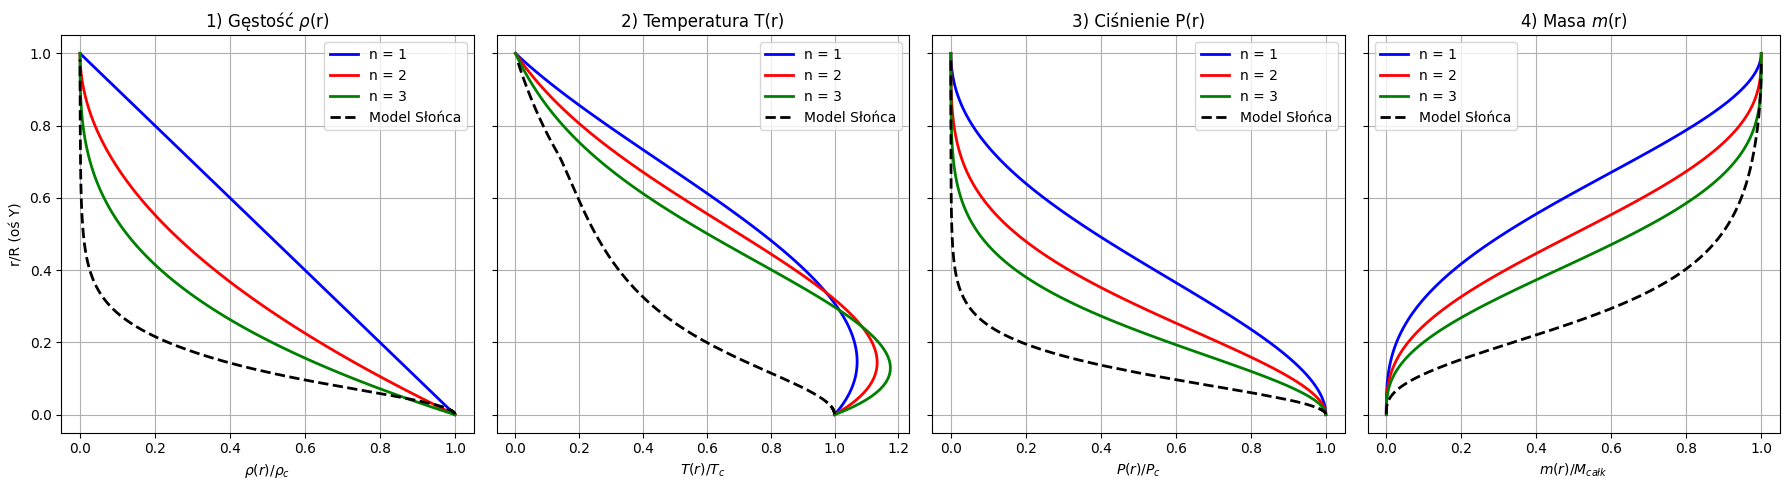

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Wczytywanie i normalizacja danych z pliku .dat
# ==========================================
# Wczytujemy plik i ignorujemy linie z komentarzami
data = np.loadtxt('Standard_Solar_Model.dat', comments='#')

# Pobieramy poszczególne kolumny
m_data   = data[:, 0]  # Kolumna 1: M/Msun
r_data   = data[:, 1]  # Kolumna 2: R/Rsun
T_data   = data[:, 2]  # Kolumna 3: T [K]
rho_data = data[:, 3]  # Kolumna 4: Rho [g/cm^3]
P_data   = data[:, 4]  # Kolumna 5: P [dyn/cm^2]

# Normalizacja parametrów do wartości centralnych Słońca (indeks 0),
# żeby zgadzały się z przedziałem 0-1 modeli teoretycznych.
T_data_norm   = T_data / T_data[0]
rho_data_norm = rho_data / rho_data[0]
P_data_norm   = P_data / P_data[0]


# ==========================================
# 2. Modele analityczne dla n=1, 2, 3
# ==========================================
r = np.linspace(0, 1, 100)

# --- Model dla n = 1 ---
rho_1 = 1 - r
m_1 = (4 - 3*r) * r**3
P_1 = 1 - (24/5)*r**2 + (28/5)*r**3 - (9/5)*r**4
T_1 = 1 + r - (19/5)*r**2 + (9/5)*r**3

# --- Model dla n = 2 ---
rho_2 = (1 - r)**2
m_2 = (10 - 15*r + 6*r**2) * r**3
P_2 = 1 - (150/13)*r**2 + (350/13)*r**3 - (345/13)*r**4 + (162/13)*r**5 - (30/13)*r**6
T_2 = 1 + 2*r - (111/13)*r**2 + (102/13)*r**3 - (30/13)*r**4

# --- Model dla n = 3 ---
rho_3 = (1 - r)**3
m_3 = (20 - 45*r + 36*r**2 - 10*r**3) * r**3
P_3 = 1 - (700/33)*r**2 + (2450/33)*r**3 - (245/2)*r**4 + (1274/11)*r**5 - (2135/33)*r**6 + 20*r**7 - (175/66)*r**8
T_3 = 1 + 3*r - (502/33)*r**2 + (680/33)*r**3 - (265/22)*r**4 + (175/66)*r**5


# ==========================================
# 3. Generowanie Wykresów
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

# Gęstość (rho)
axs[0].plot(rho_1, r, 'b-', linewidth=2, label='n = 1')
axs[0].plot(rho_2, r, 'r-', linewidth=2, label='n = 2')
axs[0].plot(rho_3, r, 'g-', linewidth=2, label='n = 3')
axs[0].plot(rho_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[0].set_ylabel('r/R (oś Y)')
axs[0].set_xlabel(r'$\rho(r) / \rho_c$')
axs[0].set_title(r'1) Gęstość $\rho$(r)')
axs[0].grid(True)
axs[0].legend()

# Temperatura (T)
axs[1].plot(T_1, r, 'b-', linewidth=2, label='n = 1')
axs[1].plot(T_2, r, 'r-', linewidth=2, label='n = 2')
axs[1].plot(T_3, r, 'g-', linewidth=2, label='n = 3')
axs[1].plot(T_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[1].set_xlabel(r'$T(r) / T_c$')
axs[1].set_title('2) Temperatura T(r)')
axs[1].grid(True)
axs[1].legend()

# Ciśnienie (P)
axs[2].plot(P_1, r, 'b-', linewidth=2, label='n = 1')
axs[2].plot(P_2, r, 'r-', linewidth=2, label='n = 2')
axs[2].plot(P_3, r, 'g-', linewidth=2, label='n = 3')
axs[2].plot(P_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[2].set_xlabel(r'$P(r) / P_c$')
axs[2].set_title('3) Ciśnienie P(r)')
axs[2].grid(True)
axs[2].legend()

# Masa (m)
axs[3].plot(m_1, r, 'b-', linewidth=2, label='n = 1') 
axs[3].plot(m_2, r, 'r-', linewidth=2, label='n = 2')
axs[3].plot(m_3, r, 'g-', linewidth=2, label='n = 3')
axs[3].plot(m_data, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[3].set_xlabel(r'$m(r) / M_{całk}$')
axs[3].set_title(r'4) Masa $m$(r)')
axs[3].grid(True)
axs[3].legend()

# Dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()

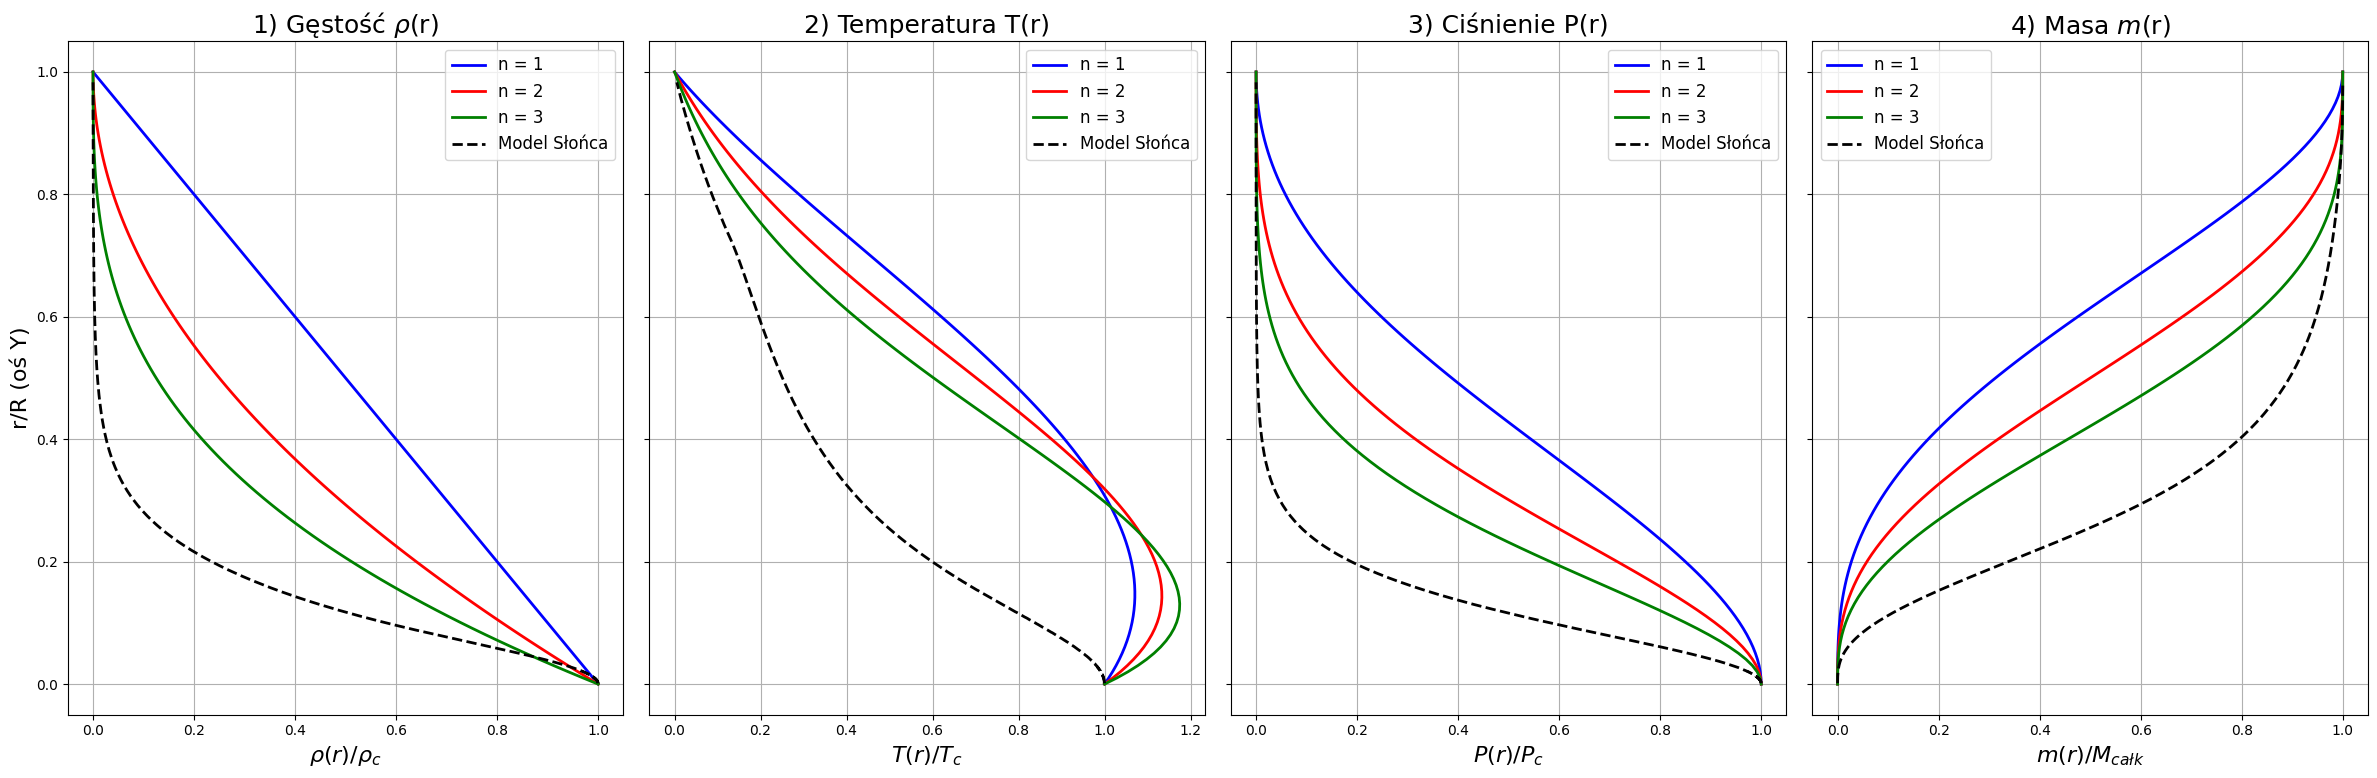

In [8]:
# ==========================================
# 3. Generowanie Wykresów
# ==========================================
# Zwiększamy figsize na (24, 8) aby uzyskać większe wykresy
fig, axs = plt.subplots(1, 4, figsize=(24, 8), sharey=True)

# Ustawiamy globalnie większy rozmiar czcionki
plt.rcParams.update({'font.size': 14})

# Gęstość (rho)
axs[0].plot(rho_1, r, 'b-', linewidth=2, label='n = 1')
axs[0].plot(rho_2, r, 'r-', linewidth=2, label='n = 2')
axs[0].plot(rho_3, r, 'g-', linewidth=2, label='n = 3')
axs[0].plot(rho_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[0].set_ylabel('r/R (oś Y)', fontsize=16)
axs[0].set_xlabel(r'$\rho(r) / \rho_c$', fontsize=16)
axs[0].set_title(r'1) Gęstość $\rho$(r)', fontsize=18)
axs[0].grid(True)
axs[0].legend(fontsize=12)

# Temperatura (T)
axs[1].plot(T_1, r, 'b-', linewidth=2, label='n = 1')
axs[1].plot(T_2, r, 'r-', linewidth=2, label='n = 2')
axs[1].plot(T_3, r, 'g-', linewidth=2, label='n = 3')
axs[1].plot(T_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[1].set_xlabel(r'$T(r) / T_c$', fontsize=16)
axs[1].set_title('2) Temperatura T(r)', fontsize=18)
axs[1].grid(True)
axs[1].legend(fontsize=12)

# Ciśnienie (P)
axs[2].plot(P_1, r, 'b-', linewidth=2, label='n = 1')
axs[2].plot(P_2, r, 'r-', linewidth=2, label='n = 2')
axs[2].plot(P_3, r, 'g-', linewidth=2, label='n = 3')
axs[2].plot(P_data_norm, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[2].set_xlabel(r'$P(r) / P_c$', fontsize=16)
axs[2].set_title('3) Ciśnienie P(r)', fontsize=18)
axs[2].grid(True)
axs[2].legend(fontsize=12)

# Masa (m)
axs[3].plot(m_1, r, 'b-', linewidth=2, label='n = 1') 
axs[3].plot(m_2, r, 'r-', linewidth=2, label='n = 2')
axs[3].plot(m_3, r, 'g-', linewidth=2, label='n = 3')
axs[3].plot(m_data, r_data, 'k--', linewidth=2, label='Model Słońca')
axs[3].set_xlabel(r'$m(r) / M_{całk}$', fontsize=16)
axs[3].set_title(r'4) Masa $m$(r)', fontsize=18)
axs[3].grid(True)
axs[3].legend(fontsize=12)

# Dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()

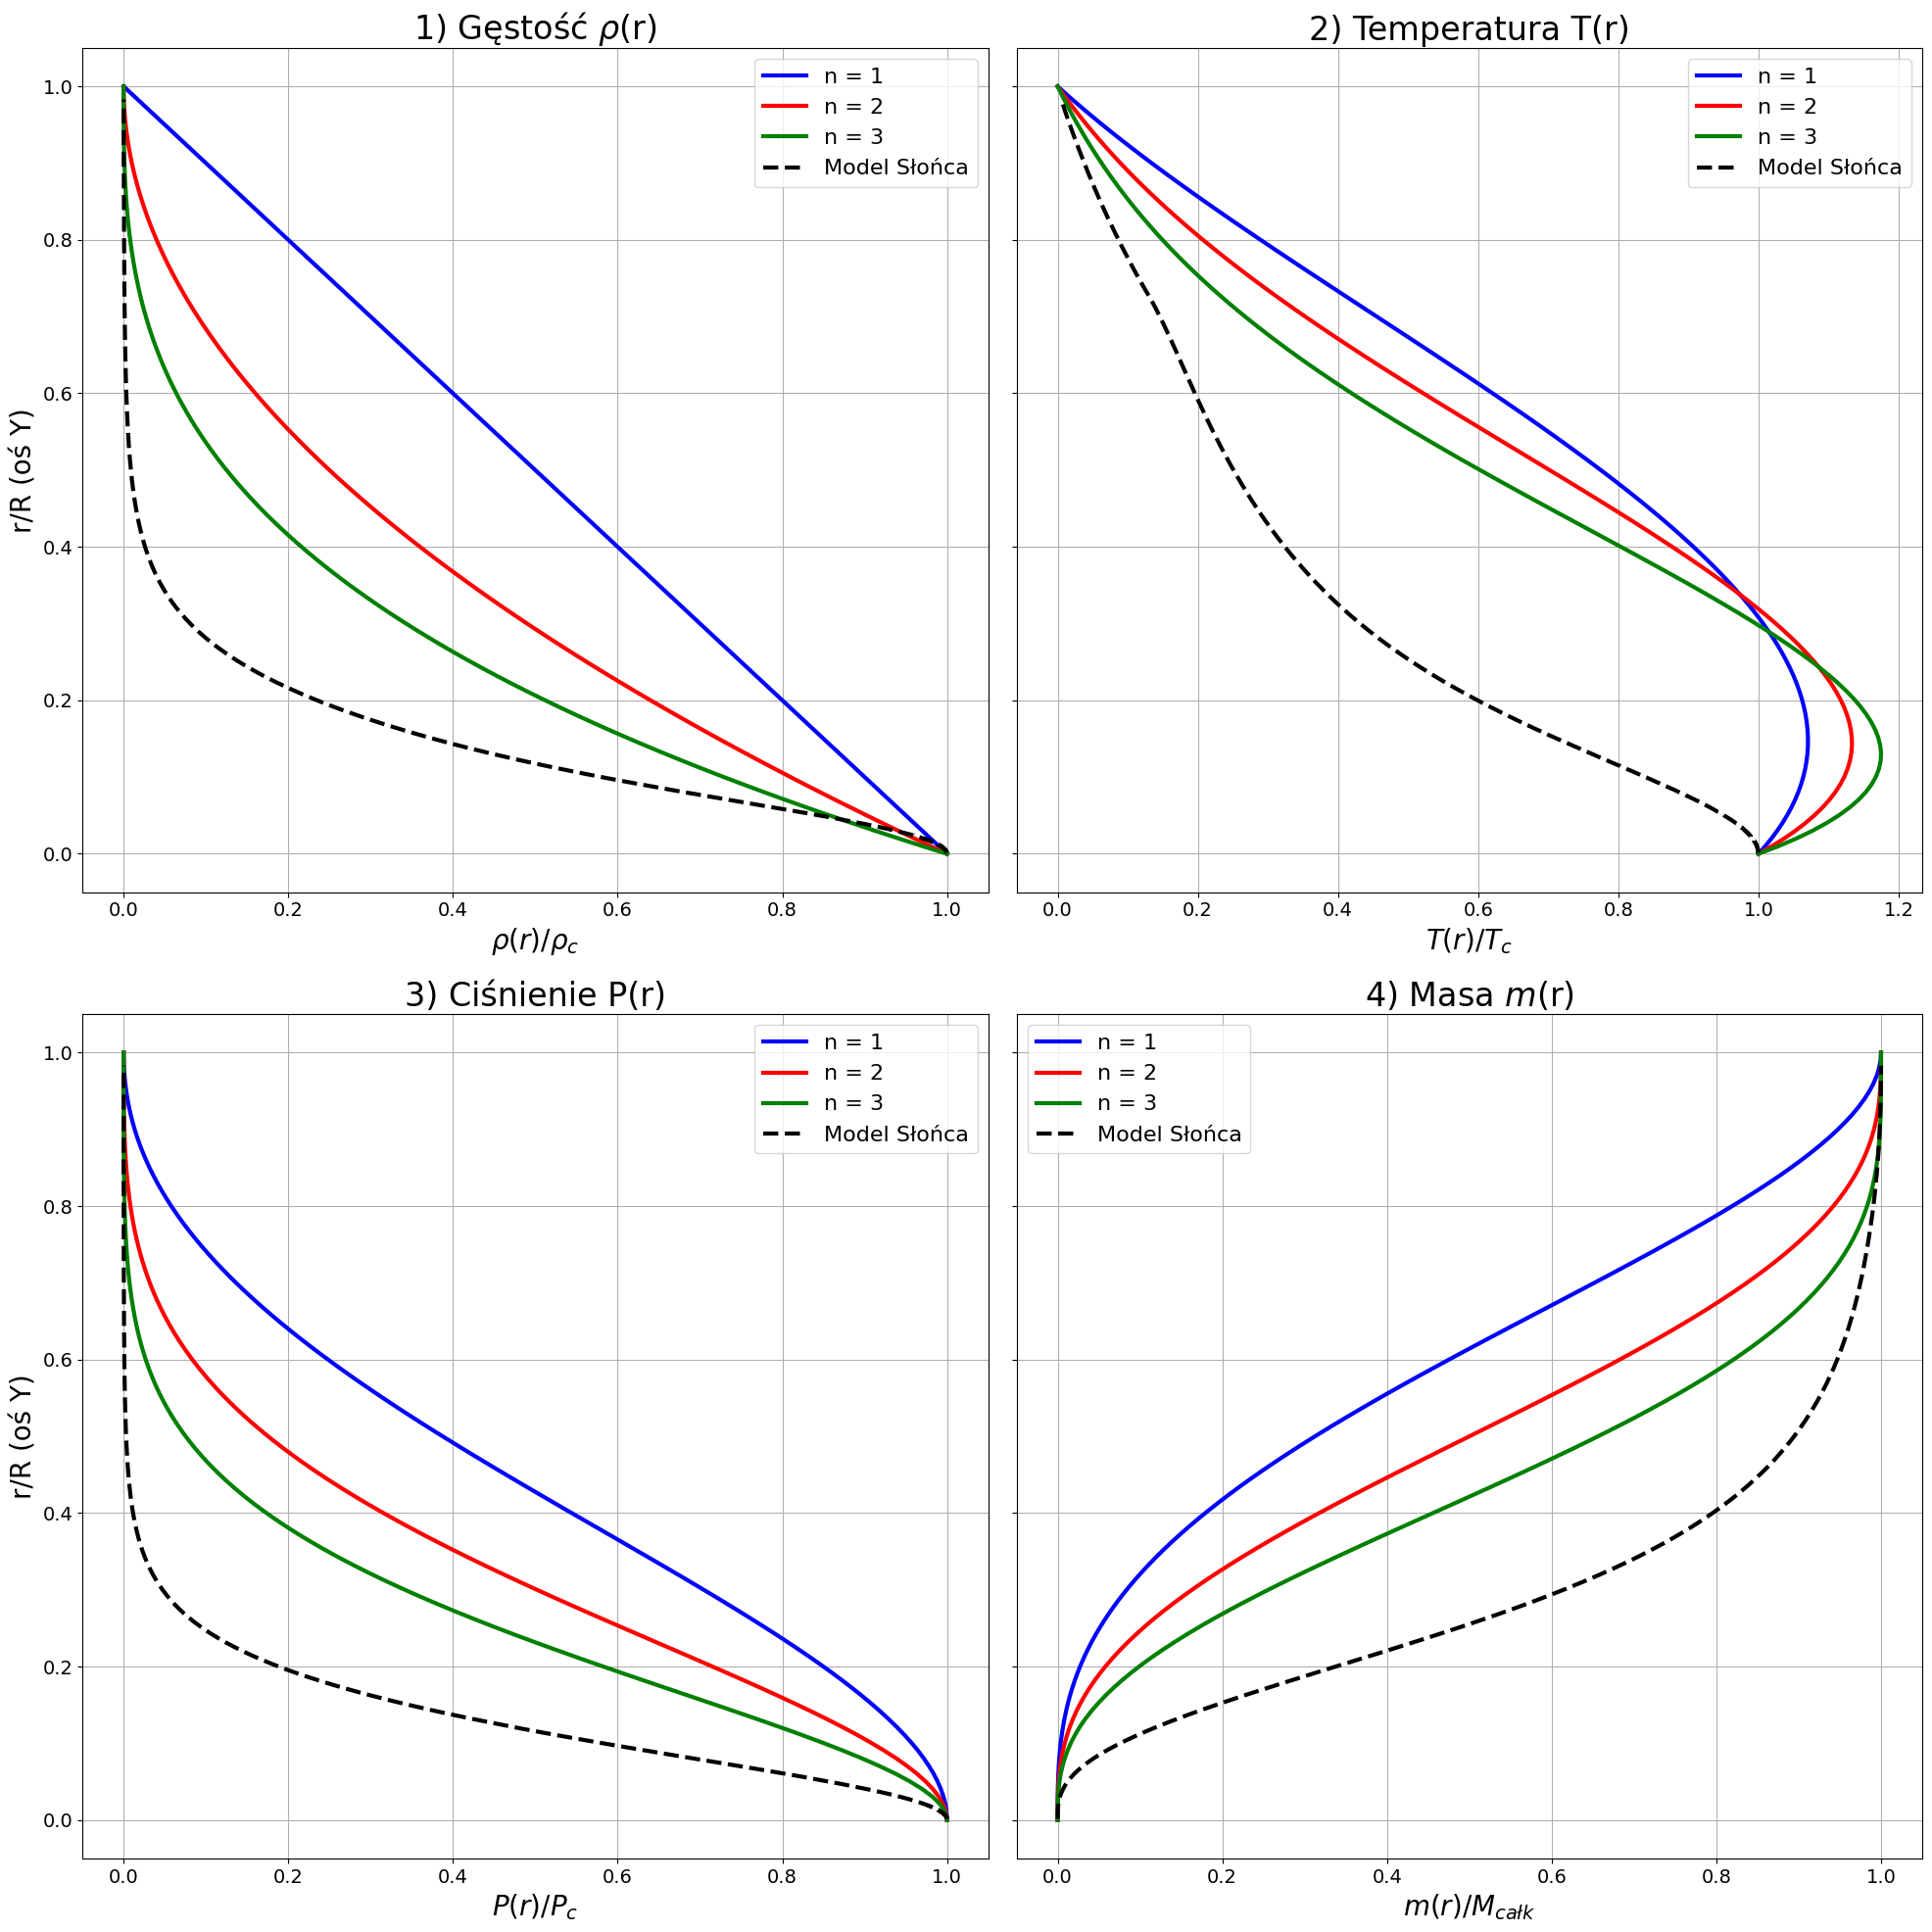

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Wczytywanie i normalizacja danych z pliku .dat
# ==========================================
# Wczytujemy plik i ignorujemy linie z komentarzami
data = np.loadtxt('Standard_Solar_Model.dat', comments='#')

# Pobieramy poszczególne kolumny
m_data   = data[:, 0]  # Kolumna 1: M/Msun
r_data   = data[:, 1]  # Kolumna 2: R/Rsun
T_data   = data[:, 2]  # Kolumna 3: T [K]
rho_data = data[:, 3]  # Kolumna 4: Rho [g/cm^3]
P_data   = data[:, 4]  # Kolumna 5: P [dyn/cm^2]

# Normalizacja parametrów do wartości centralnych Słońca
T_data_norm   = T_data / T_data[0]
rho_data_norm = rho_data / rho_data[0]
P_data_norm   = P_data / P_data[0]

# ==========================================
# 2. Modele analityczne dla n=1, 2, 3
# ==========================================
r = np.linspace(0, 1, 100)

# --- Model dla n = 1 ---
rho_1 = 1 - r
m_1 = (4 - 3*r) * r**3
P_1 = 1 - (24/5)*r**2 + (28/5)*r**3 - (9/5)*r**4
T_1 = 1 + r - (19/5)*r**2 + (9/5)*r**3

# --- Model dla n = 2 ---
rho_2 = (1 - r)**2
m_2 = (10 - 15*r + 6*r**2) * r**3
P_2 = 1 - (150/13)*r**2 + (350/13)*r**3 - (345/13)*r**4 + (162/13)*r**5 - (30/13)*r**6
T_2 = 1 + 2*r - (111/13)*r**2 + (102/13)*r**3 - (30/13)*r**4

# --- Model dla n = 3 ---
rho_3 = (1 - r)**3
m_3 = (20 - 45*r + 36*r**2 - 10*r**3) * r**3
P_3 = 1 - (700/33)*r**2 + (2450/33)*r**3 - (245/2)*r**4 + (1274/11)*r**5 - (2135/33)*r**6 + 20*r**7 - (175/66)*r**8
T_3 = 1 + 3*r - (502/33)*r**2 + (680/33)*r**3 - (265/22)*r**4 + (175/66)*r**5

# ==========================================
# 3. Generowanie Wykresów (Macierz 2x2)
# ==========================================
# Ustawiamy siatkę 2x2 i ogromny rozmiar płótna
fig, axs = plt.subplots(2, 2, figsize=(20, 20), sharey=True)

# Ustawiamy globalnie większy rozmiar czcionki i grubość linii
plt.rcParams.update({'font.size': 16})
lw = 3

# Panel 1: Gęstość (rho) -> Lewy Górny (0, 0)
axs[0, 0].plot(rho_1, r, 'b-', linewidth=lw, label='n = 1')
axs[0, 0].plot(rho_2, r, 'r-', linewidth=lw, label='n = 2')
axs[0, 0].plot(rho_3, r, 'g-', linewidth=lw, label='n = 3')
axs[0, 0].plot(rho_data_norm, r_data, 'k--', linewidth=lw, label='Model Słońca')
axs[0, 0].set_ylabel('r/R (oś Y)', fontsize=20)
axs[0, 0].set_xlabel(r'$\rho(r) / \rho_c$', fontsize=20)
axs[0, 0].set_title(r'1) Gęstość $\rho$(r)', fontsize=24)
axs[0, 0].grid(True)
axs[0, 0].legend(fontsize=16)

# Panel 2: Temperatura (T) -> Prawy Górny (0, 1)
axs[0, 1].plot(T_1, r, 'b-', linewidth=lw, label='n = 1')
axs[0, 1].plot(T_2, r, 'r-', linewidth=lw, label='n = 2')
axs[0, 1].plot(T_3, r, 'g-', linewidth=lw, label='n = 3')
axs[0, 1].plot(T_data_norm, r_data, 'k--', linewidth=lw, label='Model Słońca')
axs[0, 1].set_xlabel(r'$T(r) / T_c$', fontsize=20)
axs[0, 1].set_title('2) Temperatura T(r)', fontsize=24)
axs[0, 1].grid(True)
axs[0, 1].legend(fontsize=16)

# Panel 3: Ciśnienie (P) -> Lewy Dolny (1, 0)
axs[1, 0].plot(P_1, r, 'b-', linewidth=lw, label='n = 1')
axs[1, 0].plot(P_2, r, 'r-', linewidth=lw, label='n = 2')
axs[1, 0].plot(P_3, r, 'g-', linewidth=lw, label='n = 3')
axs[1, 0].plot(P_data_norm, r_data, 'k--', linewidth=lw, label='Model Słońca')
axs[1, 0].set_ylabel('r/R (oś Y)', fontsize=20)
axs[1, 0].set_xlabel(r'$P(r) / P_c$', fontsize=20)
axs[1, 0].set_title('3) Ciśnienie P(r)', fontsize=24)
axs[1, 0].grid(True)
axs[1, 0].legend(fontsize=16)

# Panel 4: Masa (m) -> Prawy Dolny (1, 1)
axs[1, 1].plot(m_1, r, 'b-', linewidth=lw, label='n = 1') 
axs[1, 1].plot(m_2, r, 'r-', linewidth=lw, label='n = 2')
axs[1, 1].plot(m_3, r, 'g-', linewidth=lw, label='n = 3')
axs[1, 1].plot(m_data, r_data, 'k--', linewidth=lw, label='Model Słońca')
axs[1, 1].set_xlabel(r'$m(r) / M_{całk}$', fontsize=20)
axs[1, 1].set_title(r'4) Masa $m$(r)', fontsize=24)
axs[1, 1].grid(True)
axs[1, 1].legend(fontsize=16)

# Dopasowanie układu i wyświetlenie
plt.tight_layout()
plt.show()